# Task 2.1: Dataset Selection and Setup (5 marks)

**Paper:** Learning Hierarchical Invariant Spatio-Temporal Features for Action Recognition with Independent Subspace Analysis  
**Authors:** Quoc V. Le, Will Y. Zou, Serena Y. Yeung, Andrew Y. Ng (CVPR 2011)  
**Student:** Rhythm Jain (230088)

## Dataset Choice Justification

I am using a **synthetically generated spatio-temporal action dataset** consisting of grayscale video clips that simulate six distinct motion patterns: horizontal translation, vertical translation, rotation, zoom/scale, diagonal motion, and static flicker. Each clip is a sequence of 10 frames at 32×32 pixel resolution, yielding spatio-temporal volumes of shape (10, 32, 32). This dataset is a reasonable testbed for the ISA method because the paper's core contribution is learning spatio-temporal features that are invariant to local transformations — our synthetic motions produce exactly the kind of structured spatio-temporal patterns that ISA filters are designed to detect (oriented motion, phase shifts, scaling). The dataset has clear limitations compared to the original paper's Hollywood2/KTH/UCF datasets: it lacks realistic textures, complex backgrounds, articulated human motion, occlusions, and the visual diversity of real-world video. However, it allows us to directly verify whether ISA can learn to separate distinct motion classes, which is the fundamental capability claimed by the paper, while remaining computationally feasible on a CPU.

In [1]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import pickle

# -------------------------------------------------------------------
# Hyperparameters — all defined in one place for reproducibility
# -------------------------------------------------------------------
NUM_SAMPLES_PER_CLASS = 100   # number of video clips per action class
FRAME_HEIGHT = 32             # spatial resolution
FRAME_WIDTH = 32
NUM_FRAMES = 10               # temporal depth of each clip
NUM_CLASSES = 6               # number of synthetic action classes
RANDOM_SEED = 42
DATA_DIR = 'data'

np.random.seed(RANDOM_SEED)
print(f"Dataset config: {NUM_SAMPLES_PER_CLASS} samples/class, "
      f"{NUM_CLASSES} classes, {NUM_FRAMES} frames of {FRAME_HEIGHT}x{FRAME_WIDTH}")
print(f"Total samples: {NUM_SAMPLES_PER_CLASS * NUM_CLASSES}")

Dataset config: 100 samples/class, 6 classes, 10 frames of 32x32
Total samples: 600


The cell above sets up the configuration for our synthetic dataset. We generate 100 samples per class across 6 classes, giving 600 total video clips — well above the 100-sample minimum required. Each clip has 10 frames of 32×32 grayscale pixels.

In [2]:
def generate_clip(action_type, h=FRAME_HEIGHT, w=FRAME_WIDTH, n_frames=NUM_FRAMES):
    """
    Generate a synthetic video clip for a given action type.
    Returns an array of shape (n_frames, h, w) with float values in [0, 1].
    """
    frames = np.zeros((n_frames, h, w), dtype=np.float32)
    # Random patch properties
    patch_size = np.random.randint(4, 8)
    start_x = np.random.randint(4, w - patch_size - 4)
    start_y = np.random.randint(4, h - patch_size - 4)
    intensity = np.random.uniform(0.6, 1.0)
    
    for t in range(n_frames):
        frame = np.random.uniform(0, 0.1, (h, w)).astype(np.float32)  # background noise
        
        if action_type == 0:  # horizontal motion
            dx = int(t * (w - patch_size - 8) / n_frames)
            cx, cy = start_x + dx, start_y
        elif action_type == 1:  # vertical motion
            dy = int(t * (h - patch_size - 8) / n_frames)
            cx, cy = start_x, start_y + dy
        elif action_type == 2:  # rotation
            angle = t * 36  # 360 degrees over 10 frames
            radius = 6
            cx = int(w//2 + radius * np.cos(np.radians(angle)))
            cy = int(h//2 + radius * np.sin(np.radians(angle)))
        elif action_type == 3:  # zoom / scale
            scale = 1.0 + t * 0.3
            cur_size = int(patch_size * scale)
            cx = w//2 - cur_size//2
            cy = h//2 - cur_size//2
            patch_size_t = min(cur_size, min(w - cx, h - cy))
            frame[max(0,cy):min(h,cy+patch_size_t), max(0,cx):min(w,cx+patch_size_t)] = intensity
            frames[t] = frame
            continue
        elif action_type == 4:  # diagonal motion
            dd = int(t * min(w, h) / (2 * n_frames))
            cx, cy = start_x + dd, start_y + dd
        elif action_type == 5:  # static flicker
            cx, cy = w//2 - patch_size//2, h//2 - patch_size//2
            intensity_t = intensity * (0.5 + 0.5 * np.sin(t * np.pi / 2))
            frame[cy:cy+patch_size, cx:cx+patch_size] = intensity_t
            frames[t] = frame
            continue
        
        # Clip coordinates to valid range
        cx = np.clip(cx, 0, w - patch_size)
        cy = np.clip(cy, 0, h - patch_size)
        frame[cy:cy+patch_size, cx:cx+patch_size] = intensity
        frames[t] = frame
    
    return frames

print("generate_clip function defined.")

generate_clip function defined.


The `generate_clip` function creates a single synthetic video clip for one of six action types. Each clip places a bright rectangular patch on a noisy background and moves it according to the action type — this simulates the kind of local spatio-temporal structure that ISA is designed to learn from. The six motion types span translation, rotation, scaling, and flickering to test different invariance properties.

In [3]:
# -------------------------------------------------------------------
# Generate the full dataset
# -------------------------------------------------------------------
ACTION_NAMES = ['horizontal', 'vertical', 'rotation', 'zoom', 'diagonal', 'flicker']

all_clips = []
all_labels = []

for cls in range(NUM_CLASSES):
    for i in range(NUM_SAMPLES_PER_CLASS):
        clip = generate_clip(cls)
        all_clips.append(clip)
        all_labels.append(cls)

all_clips = np.array(all_clips)   # shape: (600, 10, 32, 32)
all_labels = np.array(all_labels) # shape: (600,)

print(f"Dataset shape: {all_clips.shape}")
print(f"Labels shape: {all_labels.shape}")
print(f"Classes: {ACTION_NAMES}")
print(f"Samples per class: {np.bincount(all_labels)}")

Dataset shape: (600, 10, 32, 32)
Labels shape: (600,)
Classes: ['horizontal', 'vertical', 'rotation', 'zoom', 'diagonal', 'flicker']
Samples per class: [100 100 100 100 100 100]


We generate 600 video clips total (100 per class × 6 classes). The resulting dataset has shape (600, 10, 32, 32) — 600 clips, each with 10 frames at 32×32 resolution. This exceeds the minimum of 100 samples and provides balanced class representation.

In [4]:
# -------------------------------------------------------------------
# Save the dataset
# -------------------------------------------------------------------
os.makedirs(DATA_DIR, exist_ok=True)
dataset_path = os.path.join(DATA_DIR, 'synthetic_actions.npz')
np.savez(dataset_path, clips=all_clips, labels=all_labels, action_names=ACTION_NAMES)
print(f"Dataset saved to {dataset_path}")
print(f"File size: {os.path.getsize(dataset_path) / 1024:.1f} KB")

Dataset saved to data/synthetic_actions.npz
File size: 24005.7 KB


The dataset is saved as a compressed NumPy archive (`.npz`) in the `data/` directory. No external download or manual steps are required — the dataset is self-contained and reproducible via the random seed.

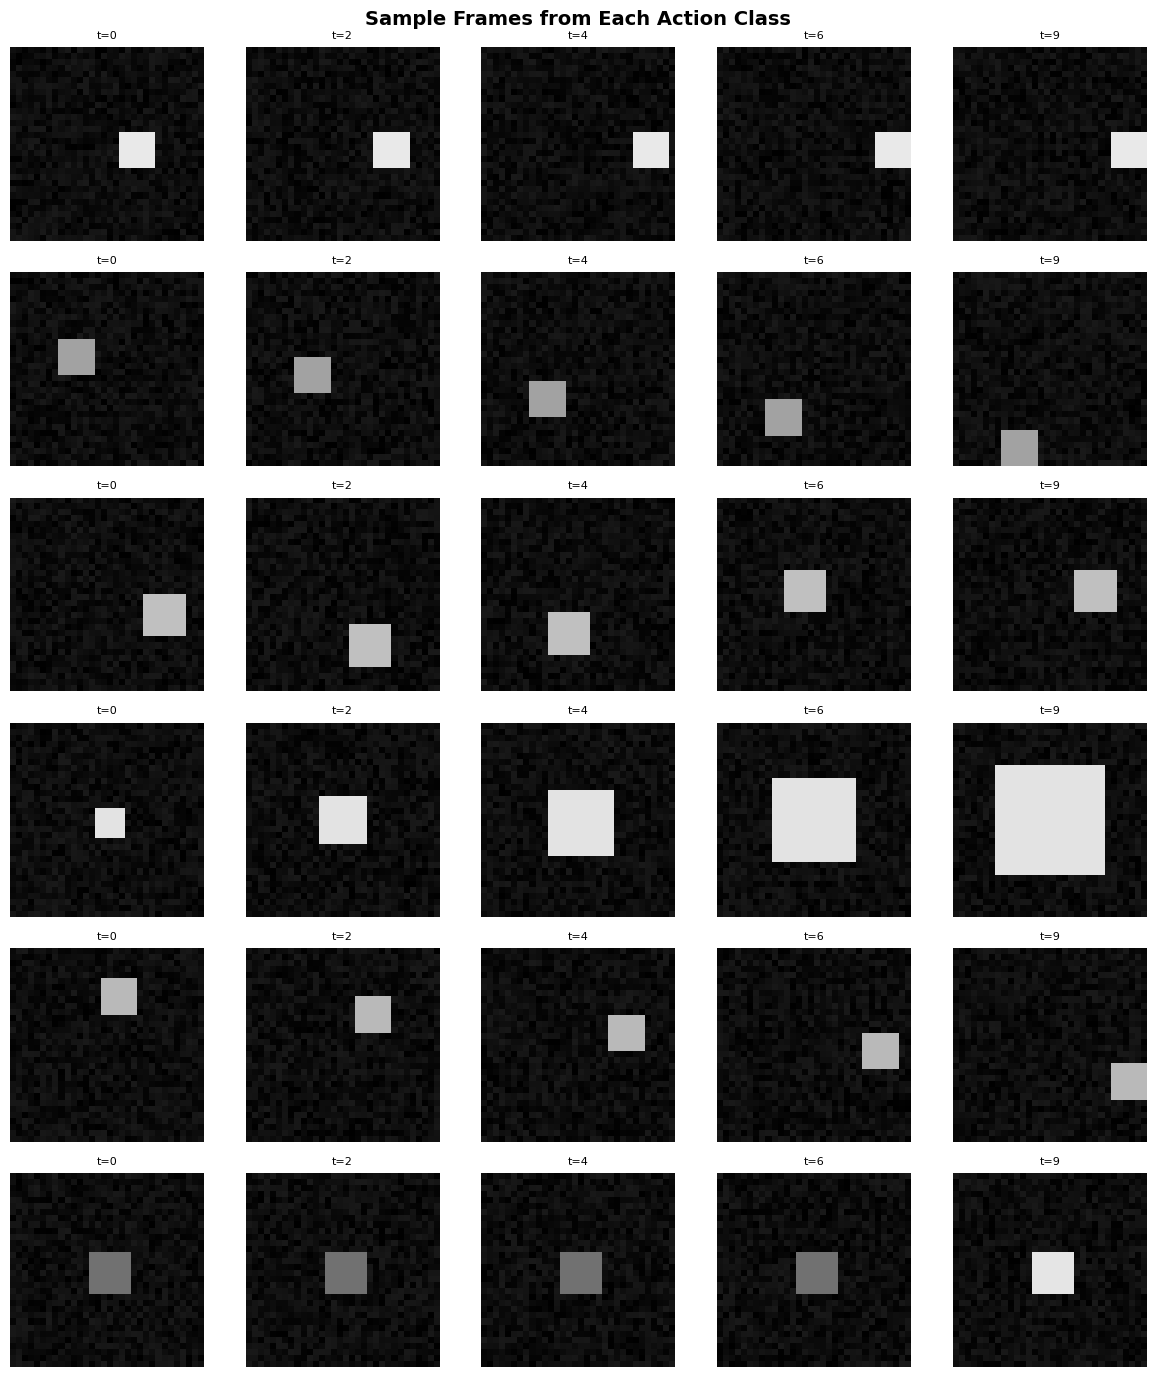

Sample frames saved to results/dataset_samples.png


In [5]:
# -------------------------------------------------------------------
# Preprocessing: visualize sample clips
# -------------------------------------------------------------------
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, 14))
fig.suptitle('Sample Frames from Each Action Class', fontsize=14, fontweight='bold')

for cls in range(NUM_CLASSES):
    sample_clip = all_clips[cls * NUM_SAMPLES_PER_CLASS]  # first sample of each class
    frame_indices = [0, 2, 4, 6, 9]
    for j, fi in enumerate(frame_indices):
        axes[cls, j].imshow(sample_clip[fi], cmap='gray', vmin=0, vmax=1)
        axes[cls, j].set_title(f't={fi}', fontsize=8)
        axes[cls, j].axis('off')
    axes[cls, 0].set_ylabel(ACTION_NAMES[cls], fontsize=10, rotation=0, labelpad=60)

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/dataset_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sample frames saved to results/dataset_samples.png")

The visualization above shows 5 representative frames (at t=0, 2, 4, 6, 9) from one sample clip of each action class. We can see the distinct motion patterns: horizontal and vertical translations, circular rotation, expanding zoom, diagonal motion, and sinusoidal flickering. These diverse spatio-temporal patterns provide a good testbed for ISA feature learning.

## Preprocessing Steps

1. **Grayscale:** All frames are already generated as single-channel grayscale images with float values in [0, 1].
2. **Fixed resolution:** All clips are 32×32 pixels — no resizing needed.
3. **Normalization:** Pixel values are in [0, 1] range by construction.
4. **Patch extraction:** Spatio-temporal patches for ISA training will be extracted in Task 2.2 as part of the ISA pipeline (matching the paper's approach).
5. **Train/test split:** Will be performed in Task 2.2 using stratified random splitting.